# Master Plotting & Artifact Management for Publication
### Project: Error Mitigation by Zero-Noise Extrapolation in Indirect-Control VQE
**Researcher:** Arijit Das, PhD Studnet | **Lab:** Owari Lab, Shizuoka University, Japan


---

## Set-up and Data Loading

### Importing Packages

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[1] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

### Ploting Set-up

In [2]:
# Set the default font to be LaTeX compliant.
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Computer Modern Roman"
plt.rcParams["text.usetex"] = True

# Set a global font size.
font_size = 11
plt.rcParams["font.size"] = font_size
plt.rcParams["axes.labelsize"] = font_size
plt.rcParams["xtick.labelsize"] = font_size
plt.rcParams["ytick.labelsize"] = font_size
plt.rcParams["legend.fontsize"] = 10

### Parsing Raw JSON Data

In [3]:
def load_simulation_data(root_dir="."):
    experiment_data = {}
    root_path = Path(root_dir)

    # Search for all .json files within directories starting with 'experiment'
    for json_file in root_path.glob("experiment*/data/**/*.json"):
        # Split the path parts: ['experiment01...', 'data', 'xy-ric2', 'file.json']
        parts = json_file.parts
        exp_name = parts[0]
        category = parts[2]  # e.g., 'xy-ric2'

        if exp_name not in experiment_data:
            experiment_data[exp_name] = {}

        if category not in experiment_data[exp_name]:
            experiment_data[exp_name][category] = []

        with open(json_file, 'r') as f:
            try:
                content = json.load(f)

                fname = json_file.name
                if "_ZNE" in fname:
                    file_type = "ZNE"
                elif "_VQE" in fname:
                    file_type = "VQE"
                elif "noise_off" in fname:
                    file_type = "noise_off"
                else:
                    file_type = "other"

                experiment_data[exp_name][category].append({
                    "filename": fname,
                    "type":     file_type,
                    "data":     content
                })
            except json.JSONDecodeError:
                print(f"Error decoding: {json_file}")

    return experiment_data
# Execute in your master.ipynb
SIMULATION_DATA = load_simulation_data()

In [4]:
print(SIMULATION_DATA.keys( ))

dict_keys(['experiment04[dephasing-time-evo-noisy]', 'experiment08[time-depol-time-evo-noisy_p1e-4_tmax100]', 'experiment00[depolarizing-time-evo-noise-free]', 'experiment07[time-depol-time-evo-noisy_p1e-3_tmax10]', 'experiment05[time-depol-time-evo-noisy_p1e-3_tmax100]', 'experiment01[depolarizing-time-evo-noisy]', 'experiment02[Dephasing noise OLD]', 'experiment06[time-depol-time-evo-noisy_p1e-3_tmax1]', 'experiment03[dephasing-time-evo-noise-free]'])


In [5]:
SIMULATION_DATA["experiment01[depolarizing-time-evo-noisy]"].keys()

dict_keys(['xy-ric6', 'xy-ric3', 'xy-ric5', 'xy-ric2', 'xy', 'xy-ric4', 'xy-ric7'])

### Computing Stats

In [6]:
# Execute
SIMULATION_DATA_STATS = get_plotting_data(SIMULATION_DATA)
print(SIMULATION_DATA_STATS.keys())

dict_keys(['experiment04[dephasing-time-evo-noisy]', 'experiment08[time-depol-time-evo-noisy_p1e-4_tmax100]', 'experiment00[depolarizing-time-evo-noise-free]', 'experiment07[time-depol-time-evo-noisy_p1e-3_tmax10]', 'experiment05[time-depol-time-evo-noisy_p1e-3_tmax100]', 'experiment01[depolarizing-time-evo-noisy]', 'experiment02[Dephasing noise OLD]', 'experiment06[time-depol-time-evo-noisy_p1e-3_tmax1]', 'experiment03[dephasing-time-evo-noise-free]'])


In [7]:
SIMULATION_DATA_STATS["experiment01[depolarizing-time-evo-noisy]"]

{'xy-ric6': {'noise_type': 'depolarizing',
  'noise_prob': [0.001, 0.001, 0.001, 0.001],
  'exact_sol': -8.566772233505624,
  'sorted_noise': [13, 47, 81, 115, 149, 183],
  'mean_exp_vals': [-6.4355046549270964,
   -3.295143445760236,
   -1.7278654435467975,
   -0.9201724866087432,
   -0.49236820988563734,
   -0.26091380448813944],
  'std_exp_vals': [0.07144654504058082,
   0.10699332304001401,
   0.09369406425089988,
   0.07099031099868375,
   0.052556618609849025,
   0.039778004557132575],
  'zne_mean': -8.33662348552183,
  'zne_std': 0.07942299397144209,
  'mean_noise_off': -8.369342611101047,
  'std_noise_off': 0.15124979844206457},
 'xy-ric3': {'noise_type': 'depolarizing',
  'noise_prob': [0.001, 0.001, 0.001, 0.001],
  'exact_sol': -8.566772233505624,
  'sorted_noise': [13, 47, 81],
  'mean_exp_vals': [-6.435504654927096,
   -3.2951434457602367,
   -1.7278654435467977],
  'std_exp_vals': [0.07144654504058066,
   0.10699332304001397,
   0.09369406425089985],
  'zne_mean': -8.0519

---

## Plotting

In [8]:
# Output directory to save plot figures
OUTPUT_DIR = "master-reports"
COLORS = {
    "noisy":      "#1f77b4",
    "zne":        "#ff7f0e",
    "exact":      "#d62728",
    "noise_free": "#0000ff",
}
TITLE_FONT_SIZE = 8
LABEL_FONT_SIZE = 8
LEGEND_FONT_SIZE = 8
TICK_FONT_SIZE = 8

### Noisy Time-Evolution

In [9]:
exp_key = "experiment01[depolarizing-time-evo-noisy]"

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'master-reports' folder): zne_depol_noisy_evo_ric4.eps
{'noise_type': 'depolarizing',
 'noise_prob': [0.001, 0.001, 0.001, 0.001],
 'exact_sol': -8.566772233505624,
 'sorted_noise': [13, 47, 81, 115],
 'mean_exp_vals': [-6.435504654927096,
                   -3.295143445760236,
                   -1.7278654435467975,
                   -0.9201724866087432],
 'std_exp_vals': [0.07144654504058125,
                  0.10699332304001406,
                  0.09369406425089992,
                  0.07099031099868372],
 'zne_mean': -8.222679067419104,
 'zne_std': 0.07642376885069371,
 'mean_noise_off': -8.369342611101047,
 'std_noise_off': 0.15124979844206457}


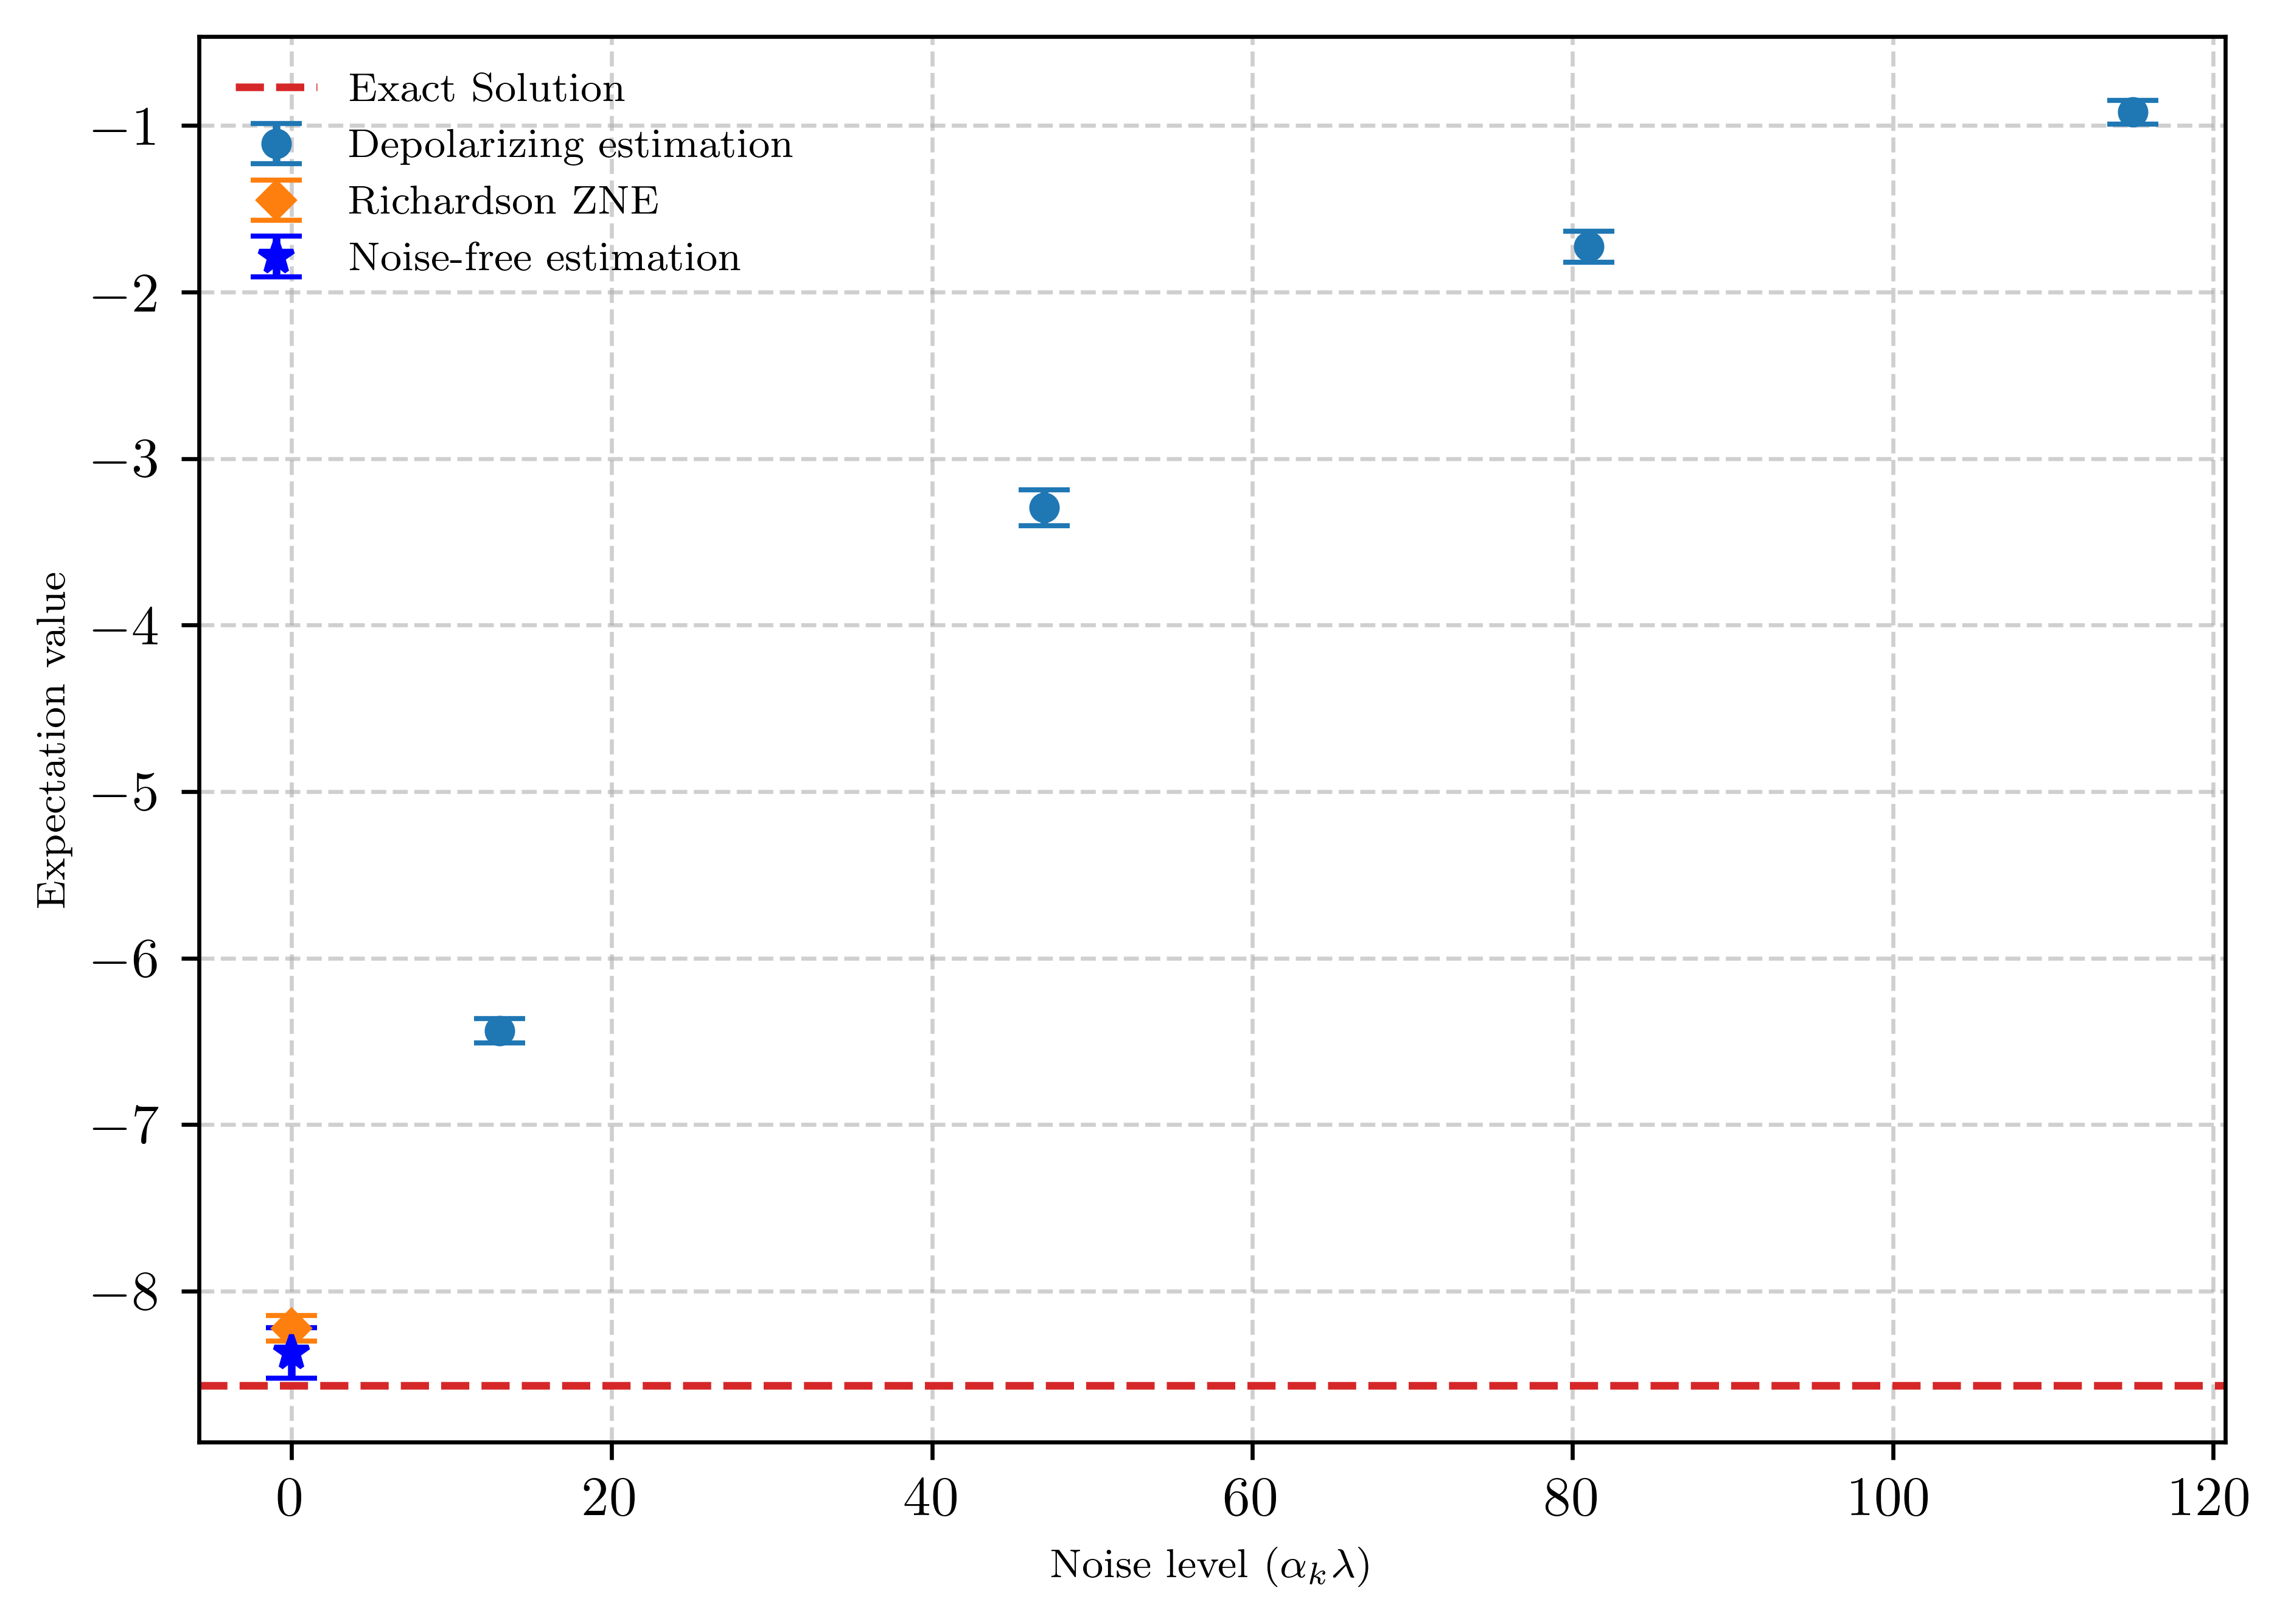

In [10]:
fig = plot_single_zne(
    data=SIMULATION_DATA_STATS[exp_key]["xy-ric4"],
    plot_colors=COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    #tick_fontsize = TICK_FONT_SIZE,
    legend_fontsize = LEGEND_FONT_SIZE,
    #plot_title="ZNE – Depolarizing noise",
    plot_file_name="zne_depol_noisy_evo_ric4",
    output_dir=OUTPUT_DIR,
    extrapol_target=0,
    save_format="eps",
    show_plot=True,
    print_data=True,
    figsize=(7.16, 5.0),   # 7.16 in wide — adjust height to taste
    dpi=600,
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'master-reports' folder): zne_depol_noisy_evo_ric4.eps
{'noise_type': 'depolarizing',
 'noise_prob': [0.001, 0.001, 0.001, 0.001],
 'exact_sol': -8.566772233505624,
 'sorted_noise': [13, 47, 81, 115],
 'mean_exp_vals': [-6.435504654927096,
                   -3.295143445760236,
                   -1.7278654435467975,
                   -0.9201724866087432],
 'std_exp_vals': [0.07144654504058125,
                  0.10699332304001406,
                  0.09369406425089992,
                  0.07099031099868372],
 'zne_mean': -8.222679067419104,
 'zne_std': 0.07642376885069371,
 'mean_noise_off': -8.369342611101047,
 'std_noise_off': 0.15124979844206457}


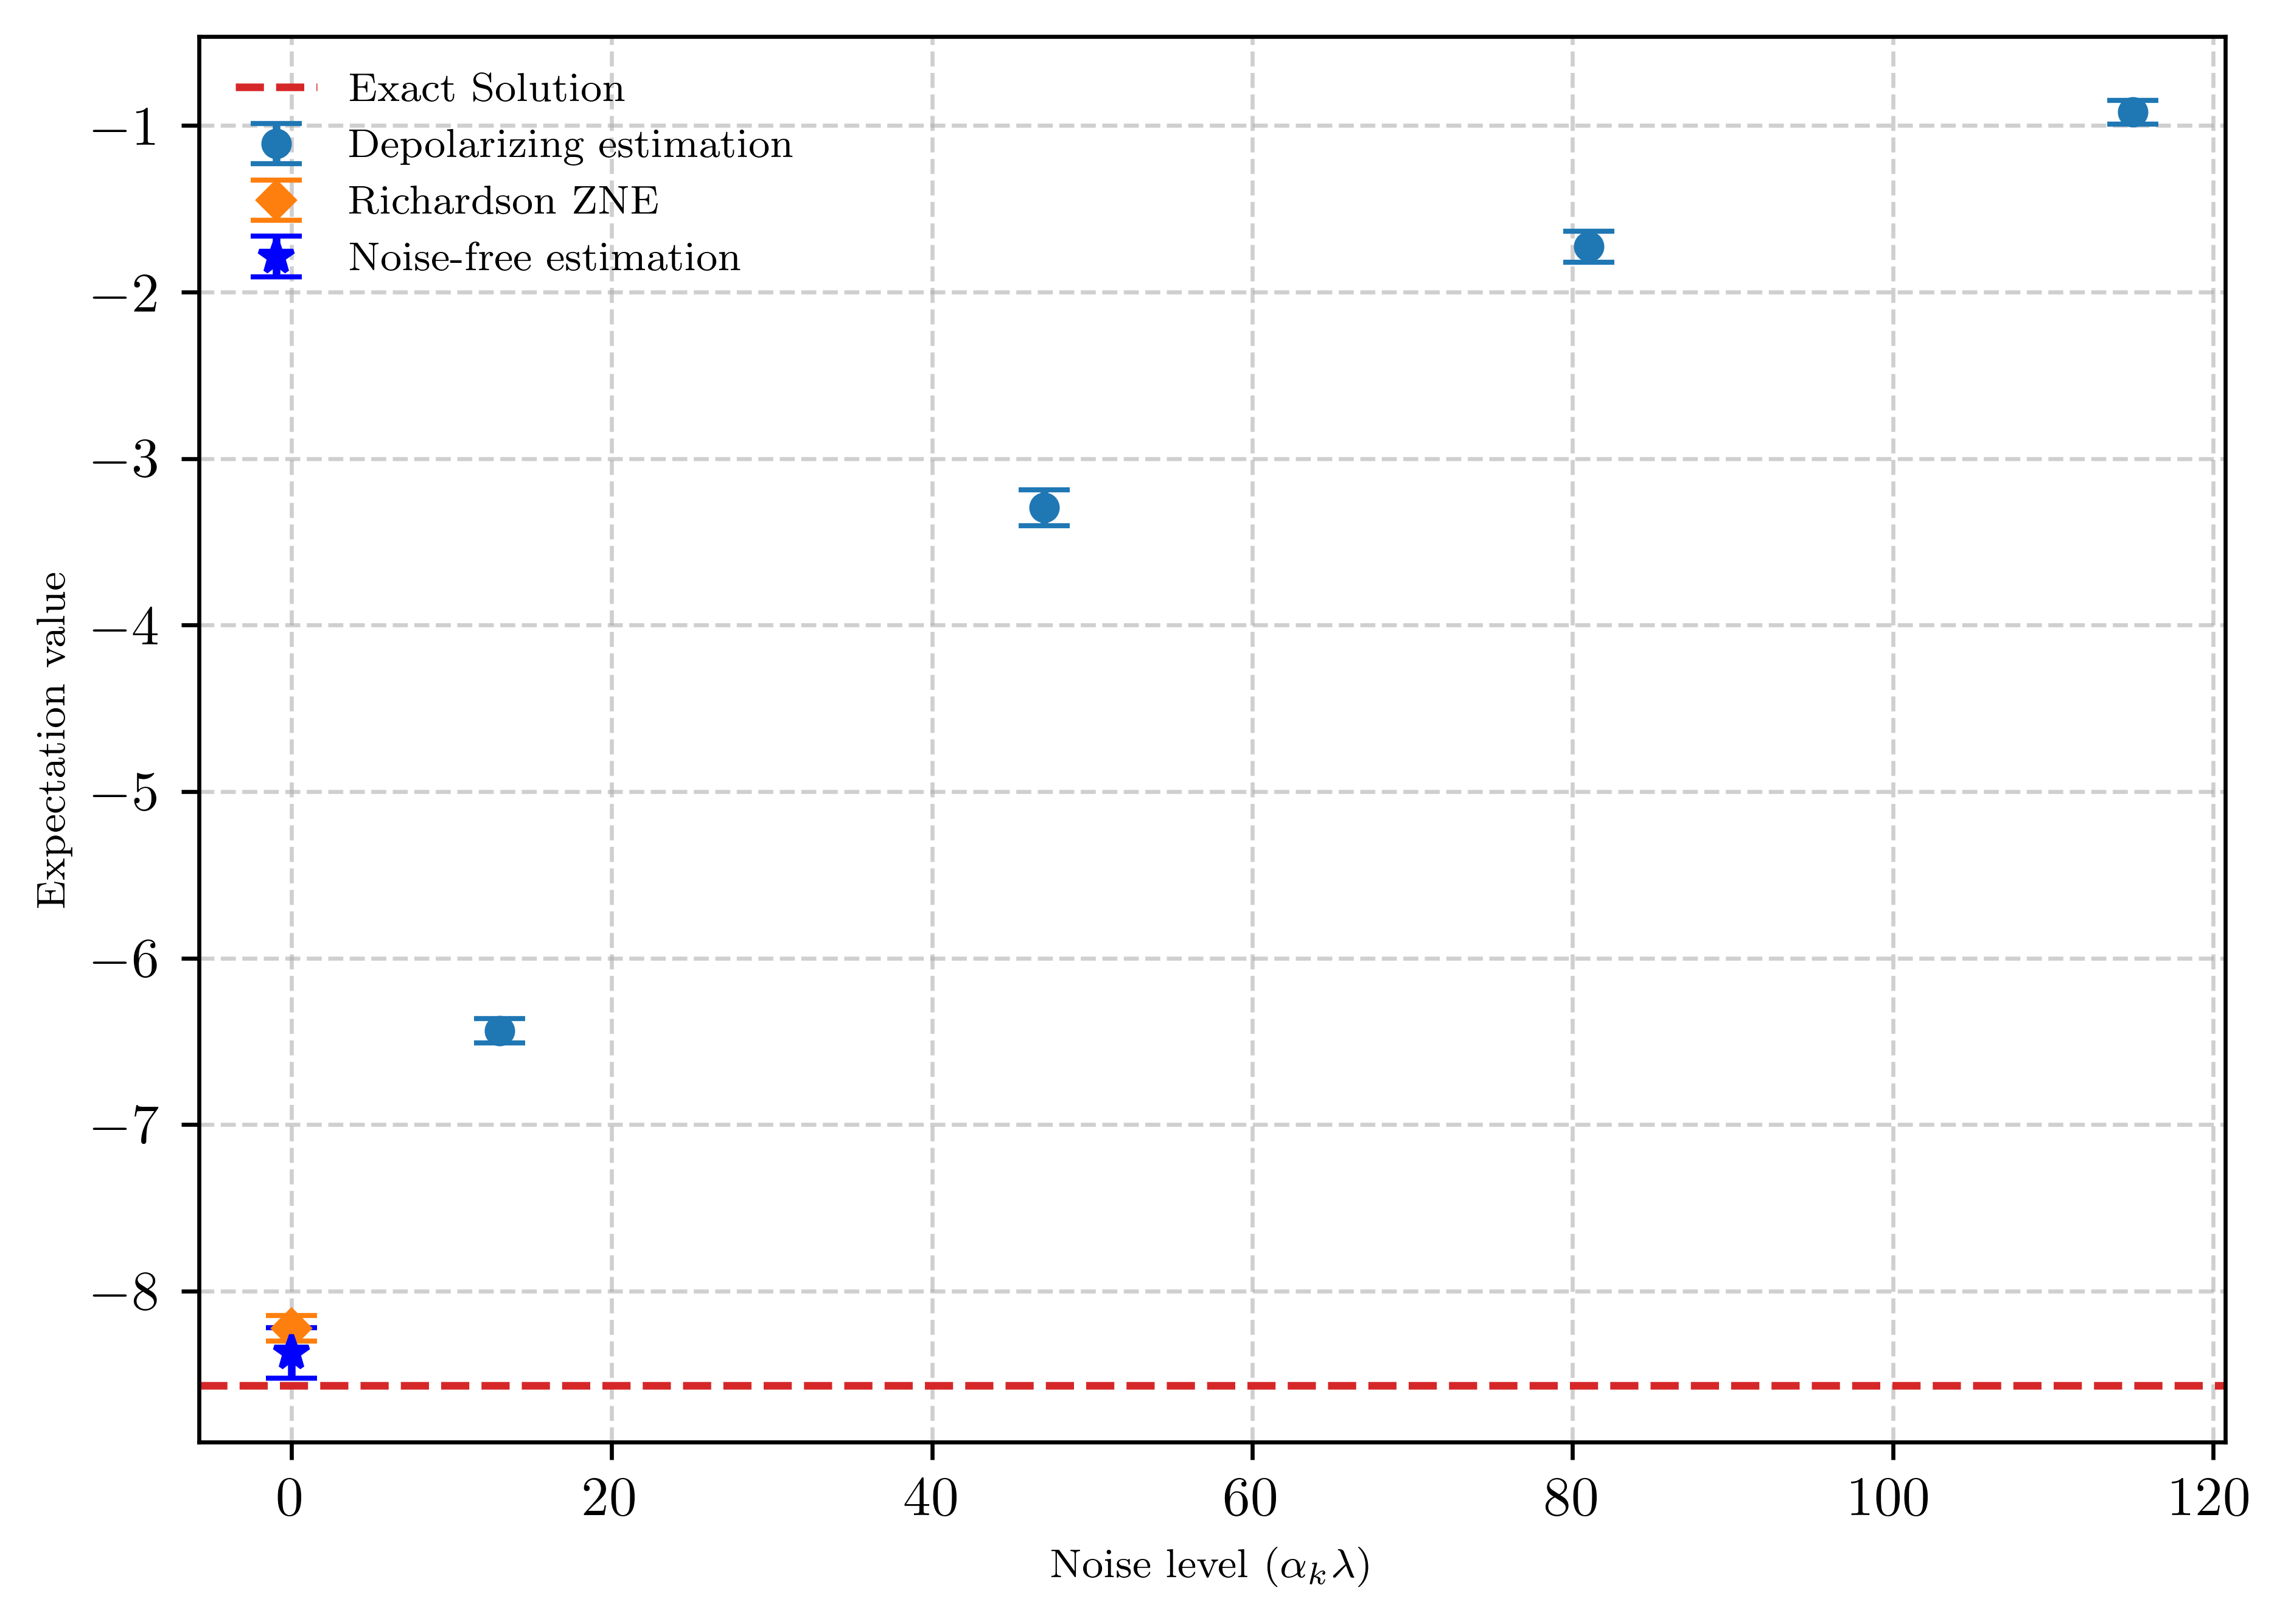

In [11]:
fig = plot_single_zne(
    data=SIMULATION_DATA_STATS[exp_key]["xy-ric4"],
    plot_colors=COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    #tick_fontsize = TICK_FONT_SIZE,
    legend_fontsize = LEGEND_FONT_SIZE,
    #plot_title="ZNE – Depolarizing noise",
    plot_file_name="zne_depol_noisy_evo_ric4",
    output_dir=OUTPUT_DIR,
    extrapol_target=0,
    save_format="eps",
    show_plot=True,
    print_data=True,
    figsize=(7.16, 5.0),   # 7.16 in wide — adjust height to taste
    dpi=600,
)

✅ Figure saved as (in 'master-reports' folder): zne_grid_exp01.png


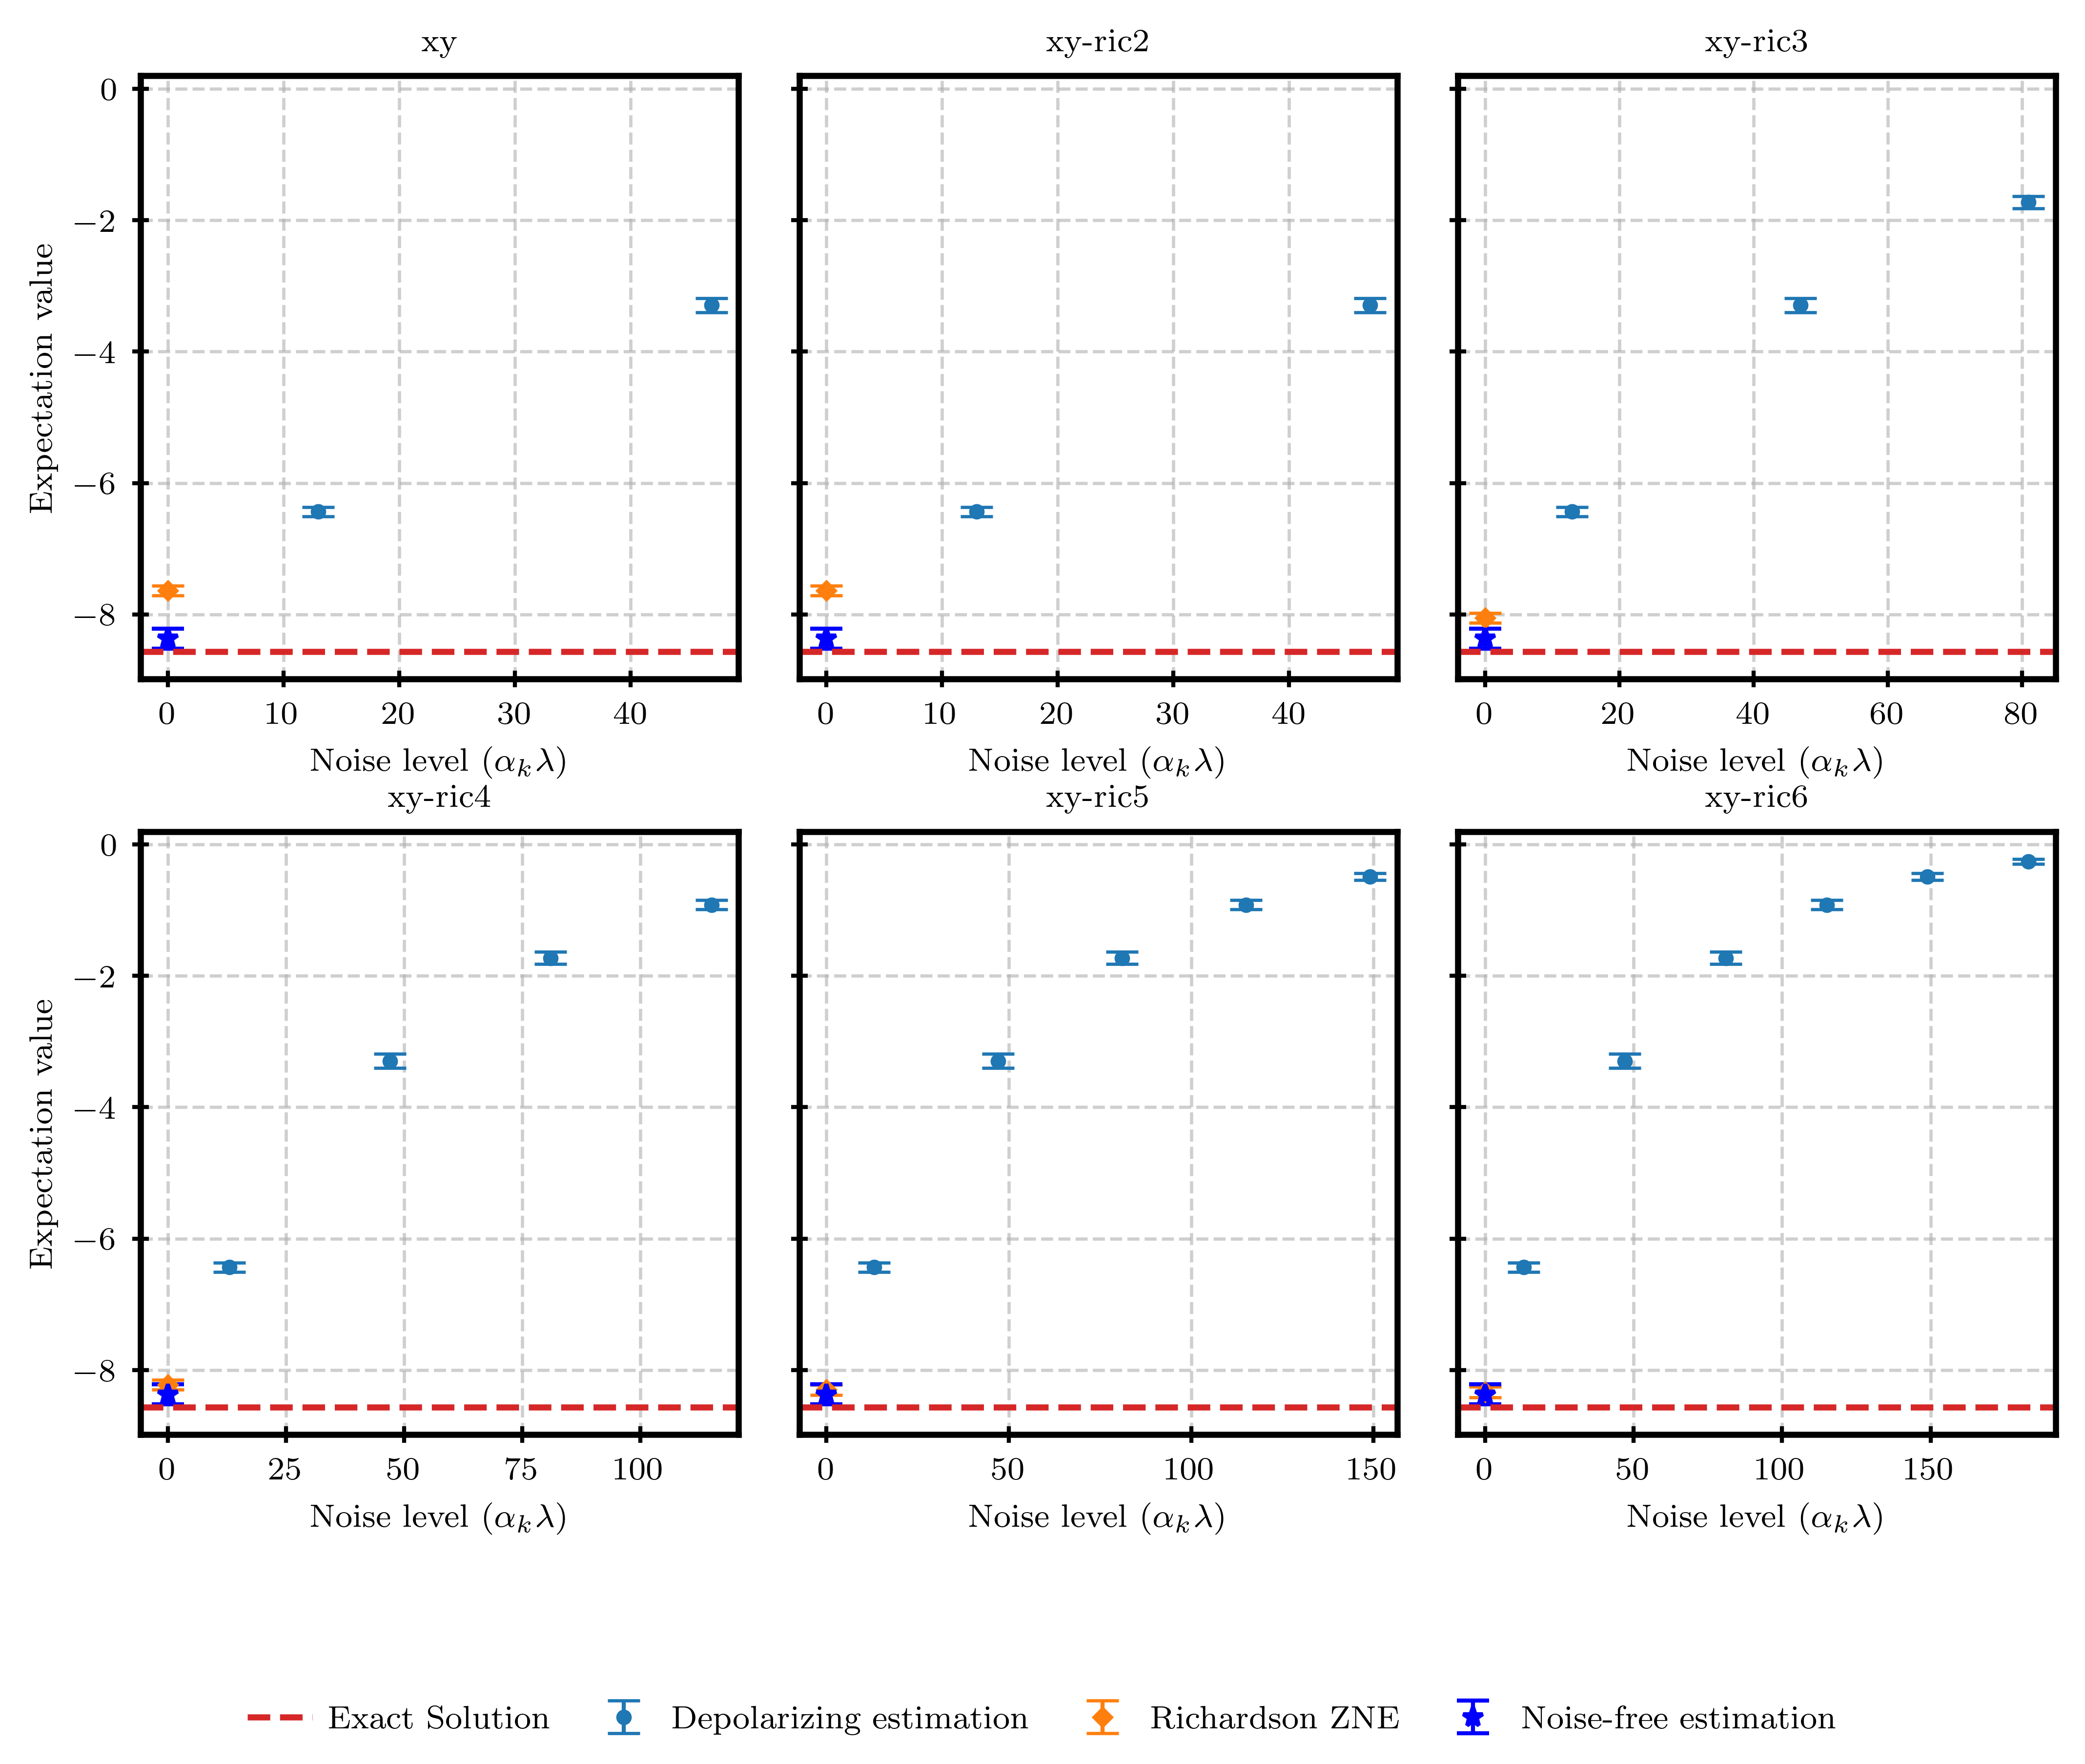

In [12]:
# pick which subcategories to include and in which order
subkeys = ["xy", "xy-ric2", "xy-ric3", "xy-ric4", "xy-ric5", "xy-ric6"]

data_list   = [SIMULATION_DATA_STATS[exp_key][k] for k in subkeys]
plot_titles = subkeys   # or any custom labels you want per panel

fig = plot_multi_zne(
    data_list      = data_list,
    plot_titles    = plot_titles,
    plot_colors    = COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    tick_fontsize = TICK_FONT_SIZE,
    marker_size = 3,
    legend_fontsize = LEGEND_FONT_SIZE,
    plot_file_name = "zne_grid_exp01",
    output_dir     = OUTPUT_DIR,
    extrapol_target= 0,
    ncols          = 3,
    figsize=(7.16, 6.0),   # 7.16 in wide — adjust height to taste
    dpi=600,
    sharex         = False,
    sharey         = True,
    show_legend    = True,
    global_legend  = True,       # single shared legend at bottom
    #legend_loc     = "lower center",
    save_format    = "png",
    show_plot      = True,
    print_data     = False,
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'master-reports' folder): zne_depol_vs_dephasing_IEE.eps


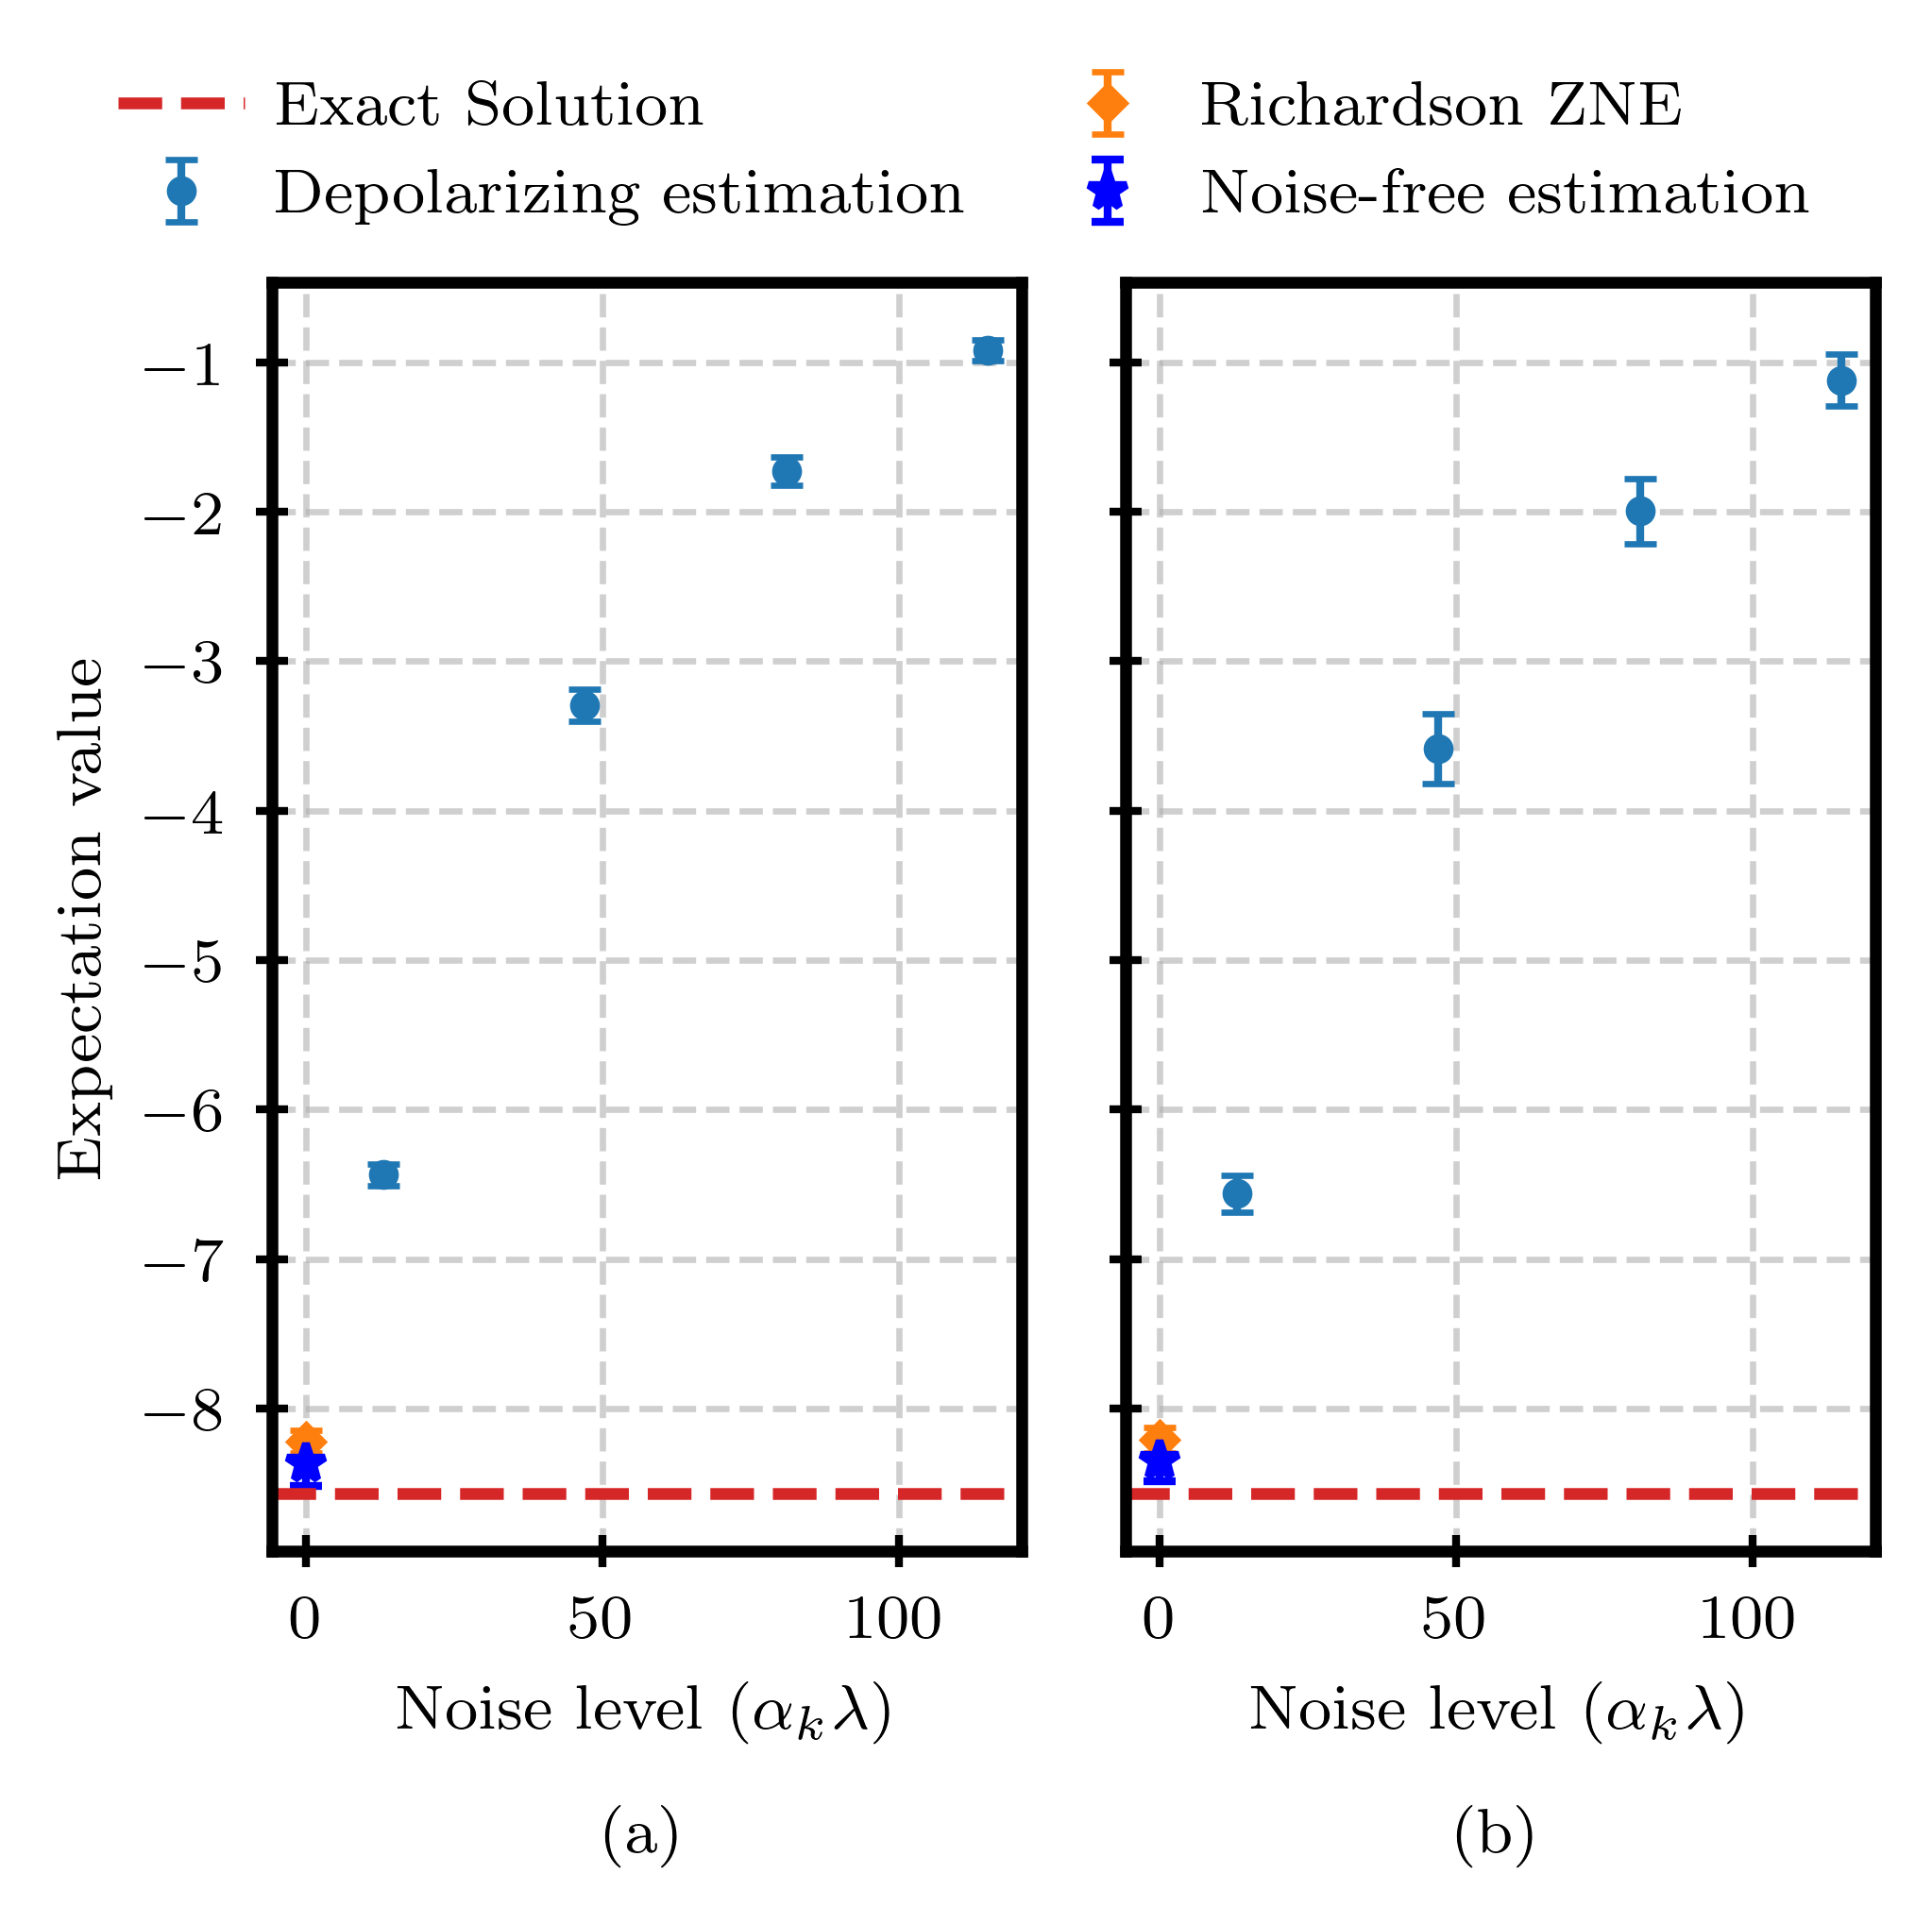

In [13]:
exp_depol = SIMULATION_DATA_STATS["experiment01[depolarizing-time-evo-noisy]"]["xy-ric4"]
exp_deph  = SIMULATION_DATA_STATS["experiment04[dephasing-time-evo-noisy]"]["xy-ric4"]

data_list   = [exp_depol, exp_deph]
plot_titles = ["(a)", "(b)"]

fig = plot_multi_zne(
    data_list             = data_list,
    plot_colors           = COLORS,
    title_fontsize = TITLE_FONT_SIZE,
    label_fontsize = LABEL_FONT_SIZE,
    tick_fontsize = TICK_FONT_SIZE,
    legend_fontsize = LEGEND_FONT_SIZE,
    marker_size = 3,
    capsize = 2,
    plot_file_name        = "zne_depol_vs_dephasing_IEE",
    output_dir            = OUTPUT_DIR,
    plot_titles           = ["(a)", "(b)"],
    panel_label_y         = -0.20,       # ← nudge up/down until it clears xlabel
    ncols                 = 2,
    figsize               = (3.45, 3.5),
    dpi                   = 600,
    sharey                = True,
    show_legend           = True,
    global_legend         = True,
    legend_loc            = "upper center",
    legend_bbox           = (0.5, 0.95),  # ← (x, y) in figure coords; raise y if clipping
    legend_ncols          = 2,
    subplot_top           = 0.82,        # ← shrink subplots to make room for legend
    subplot_bottom        = 0.18,        # ← make room for panel labels below xlabel
    save_format           = "eps",
    show_plot             = True,
)

### Noisy-Free Time-Evolution

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'master-reports' folder): zne_noisefree_xy_depol_IEE.eps


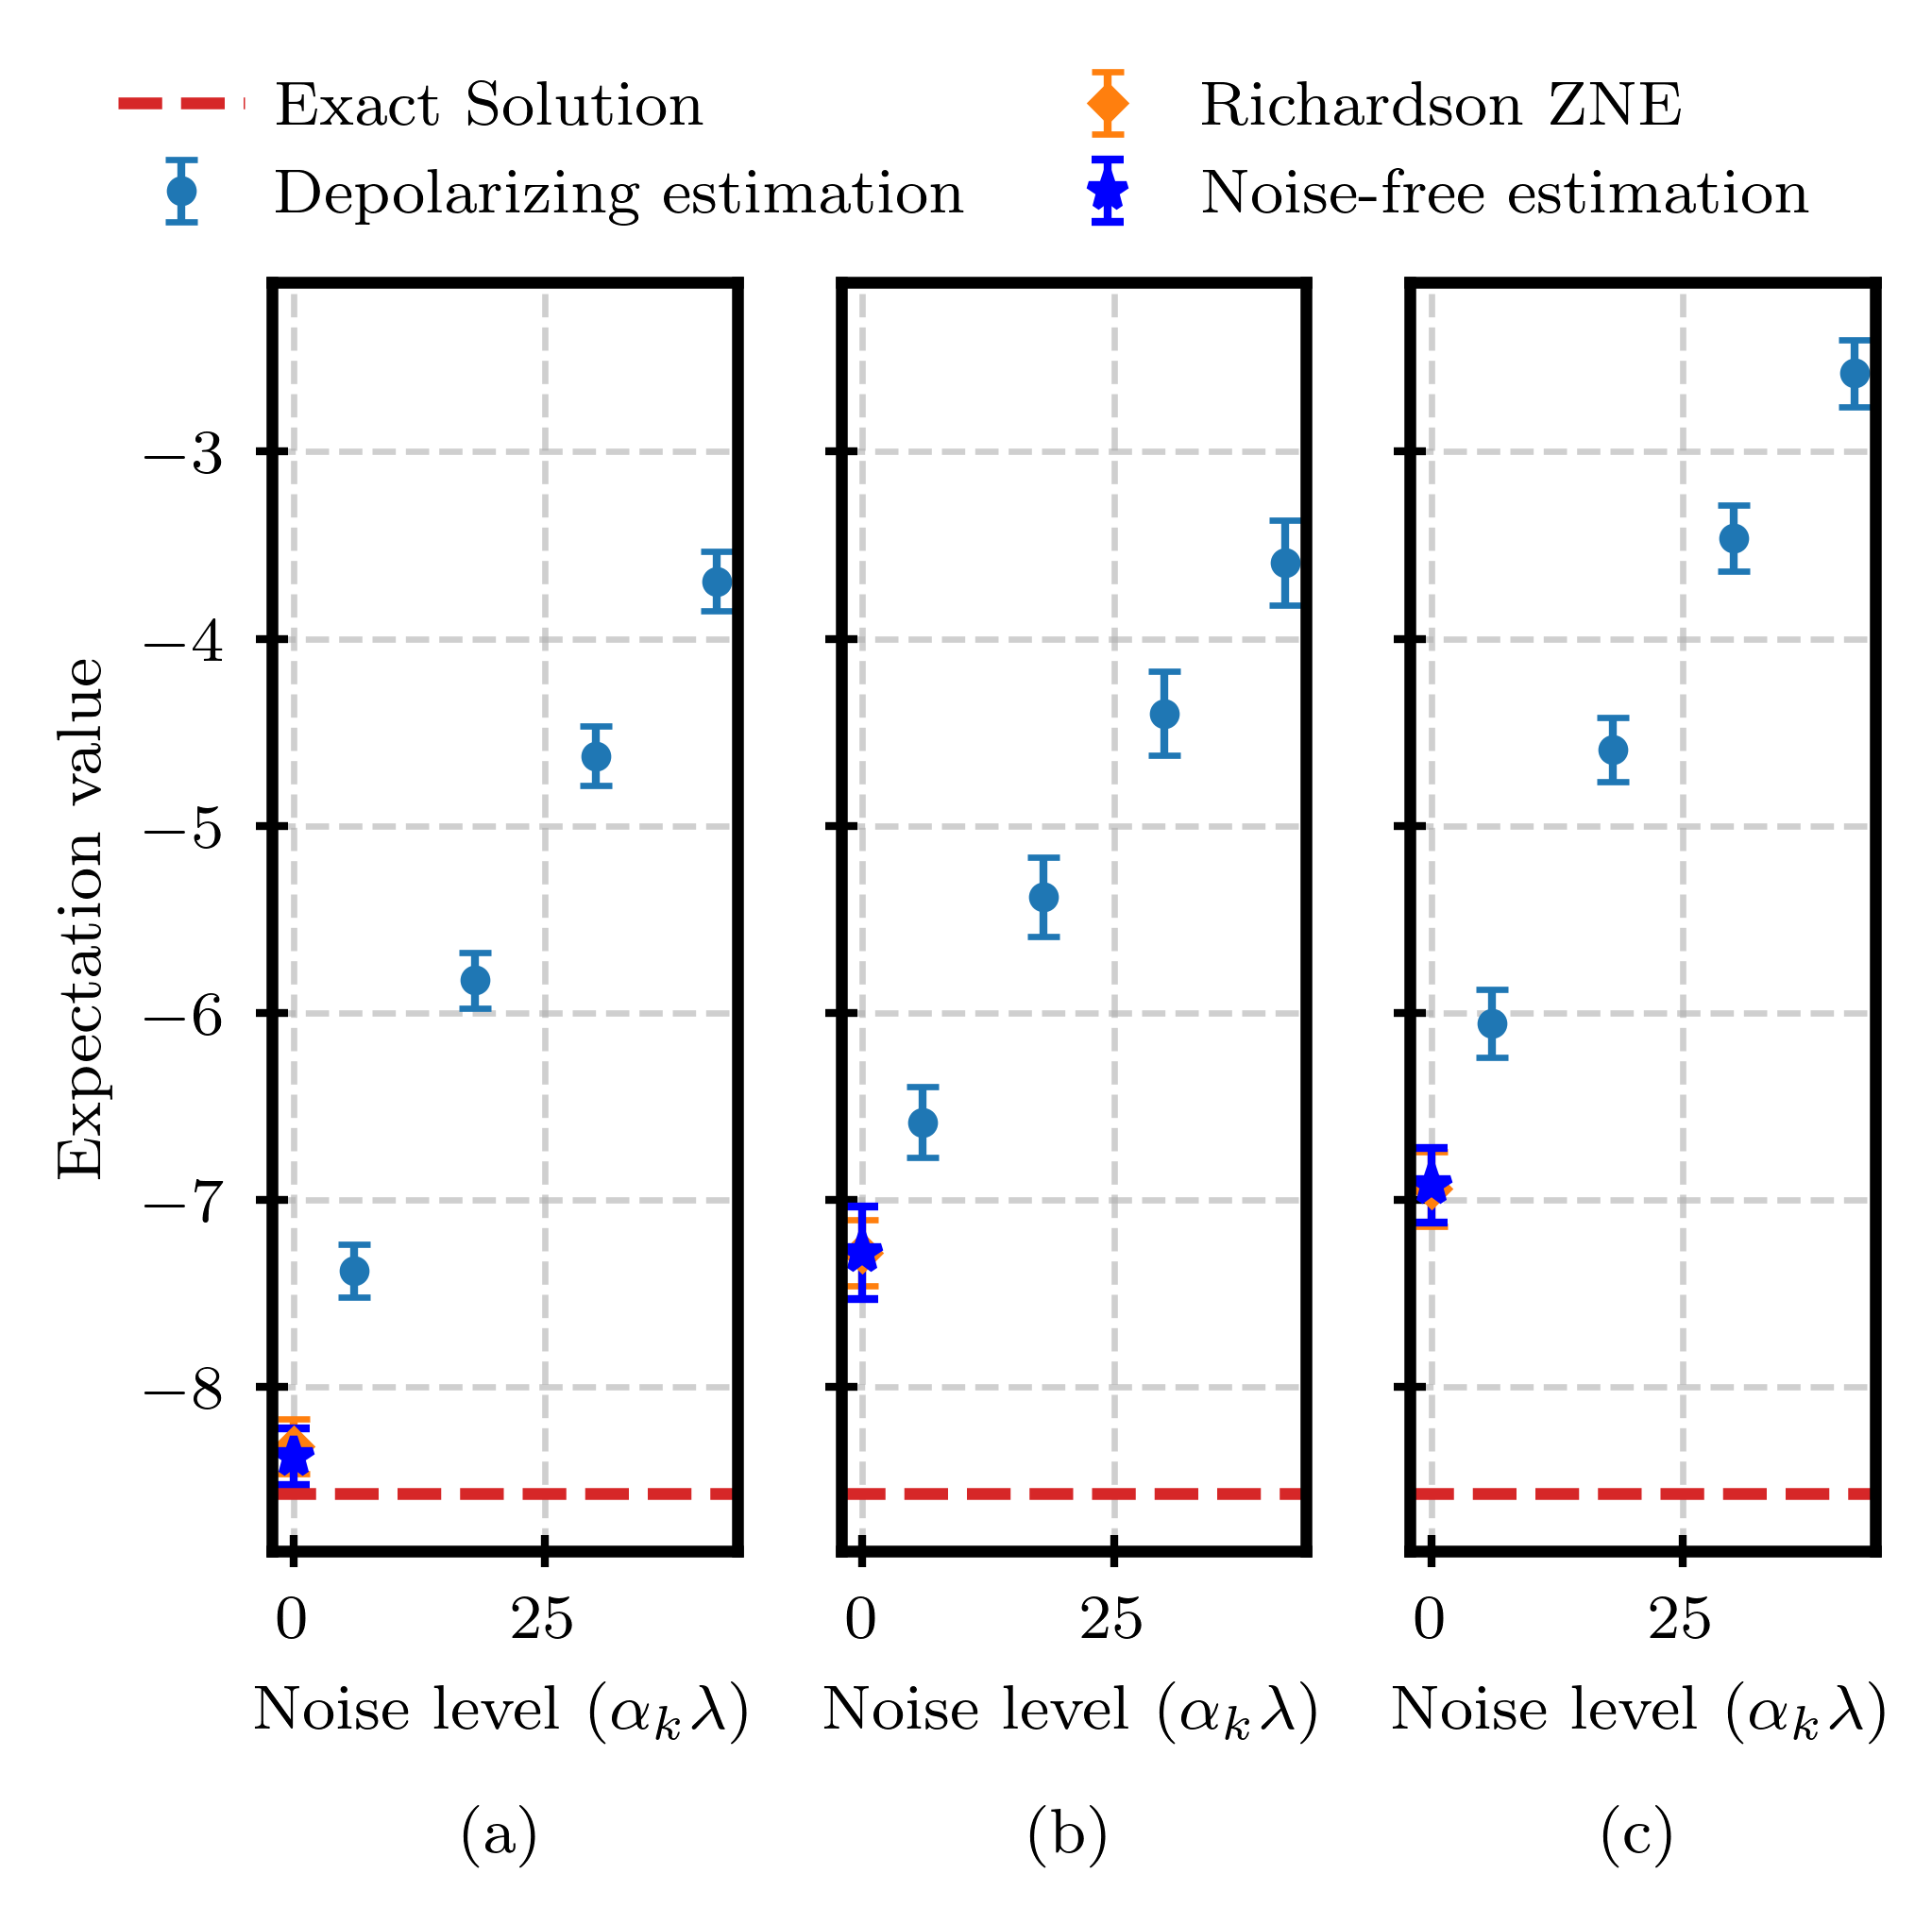

In [14]:
exp_depol = "experiment00[depolarizing-time-evo-noise-free]"

subkeys = ['xy-ric4-uniform-scaling', 'ising-ric4-uniform-scaling', 'heisenberg-ric4-uniform-scaling']

data_list = [SIMULATION_DATA_STATS[exp_depol][k] for k in subkeys]

fig = plot_multi_zne(
    data_list             = data_list,
    sharex                = True,
    plot_colors           = COLORS,
    title_fontsize        = TITLE_FONT_SIZE,
    label_fontsize        = LABEL_FONT_SIZE,
    tick_fontsize         = TICK_FONT_SIZE,
    legend_fontsize       = LEGEND_FONT_SIZE,
    marker_size           = 3,
    capsize               = 2,
    plot_file_name        = "zne_noisefree_xy_depol_IEE",
    output_dir            = OUTPUT_DIR,
    plot_titles           = ["(a)", "(b)", "(c)"],
    panel_label_y         = -0.20,
    ncols                 = 3,
    figsize               = (3.45, 3.5),
    dpi                   = 600,
    sharey                = True,
    show_legend           = True,
    global_legend         = True,
    legend_loc            = "upper center",
    legend_bbox           = (0.5, 0.95),
    legend_ncols          = 2,
    subplot_top           = 0.82,
    subplot_bottom        = 0.18,
    save_format           = "eps",
    show_plot             = True,
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'master-reports' folder): zne_noisefree_xy_dphasing_IEE.eps


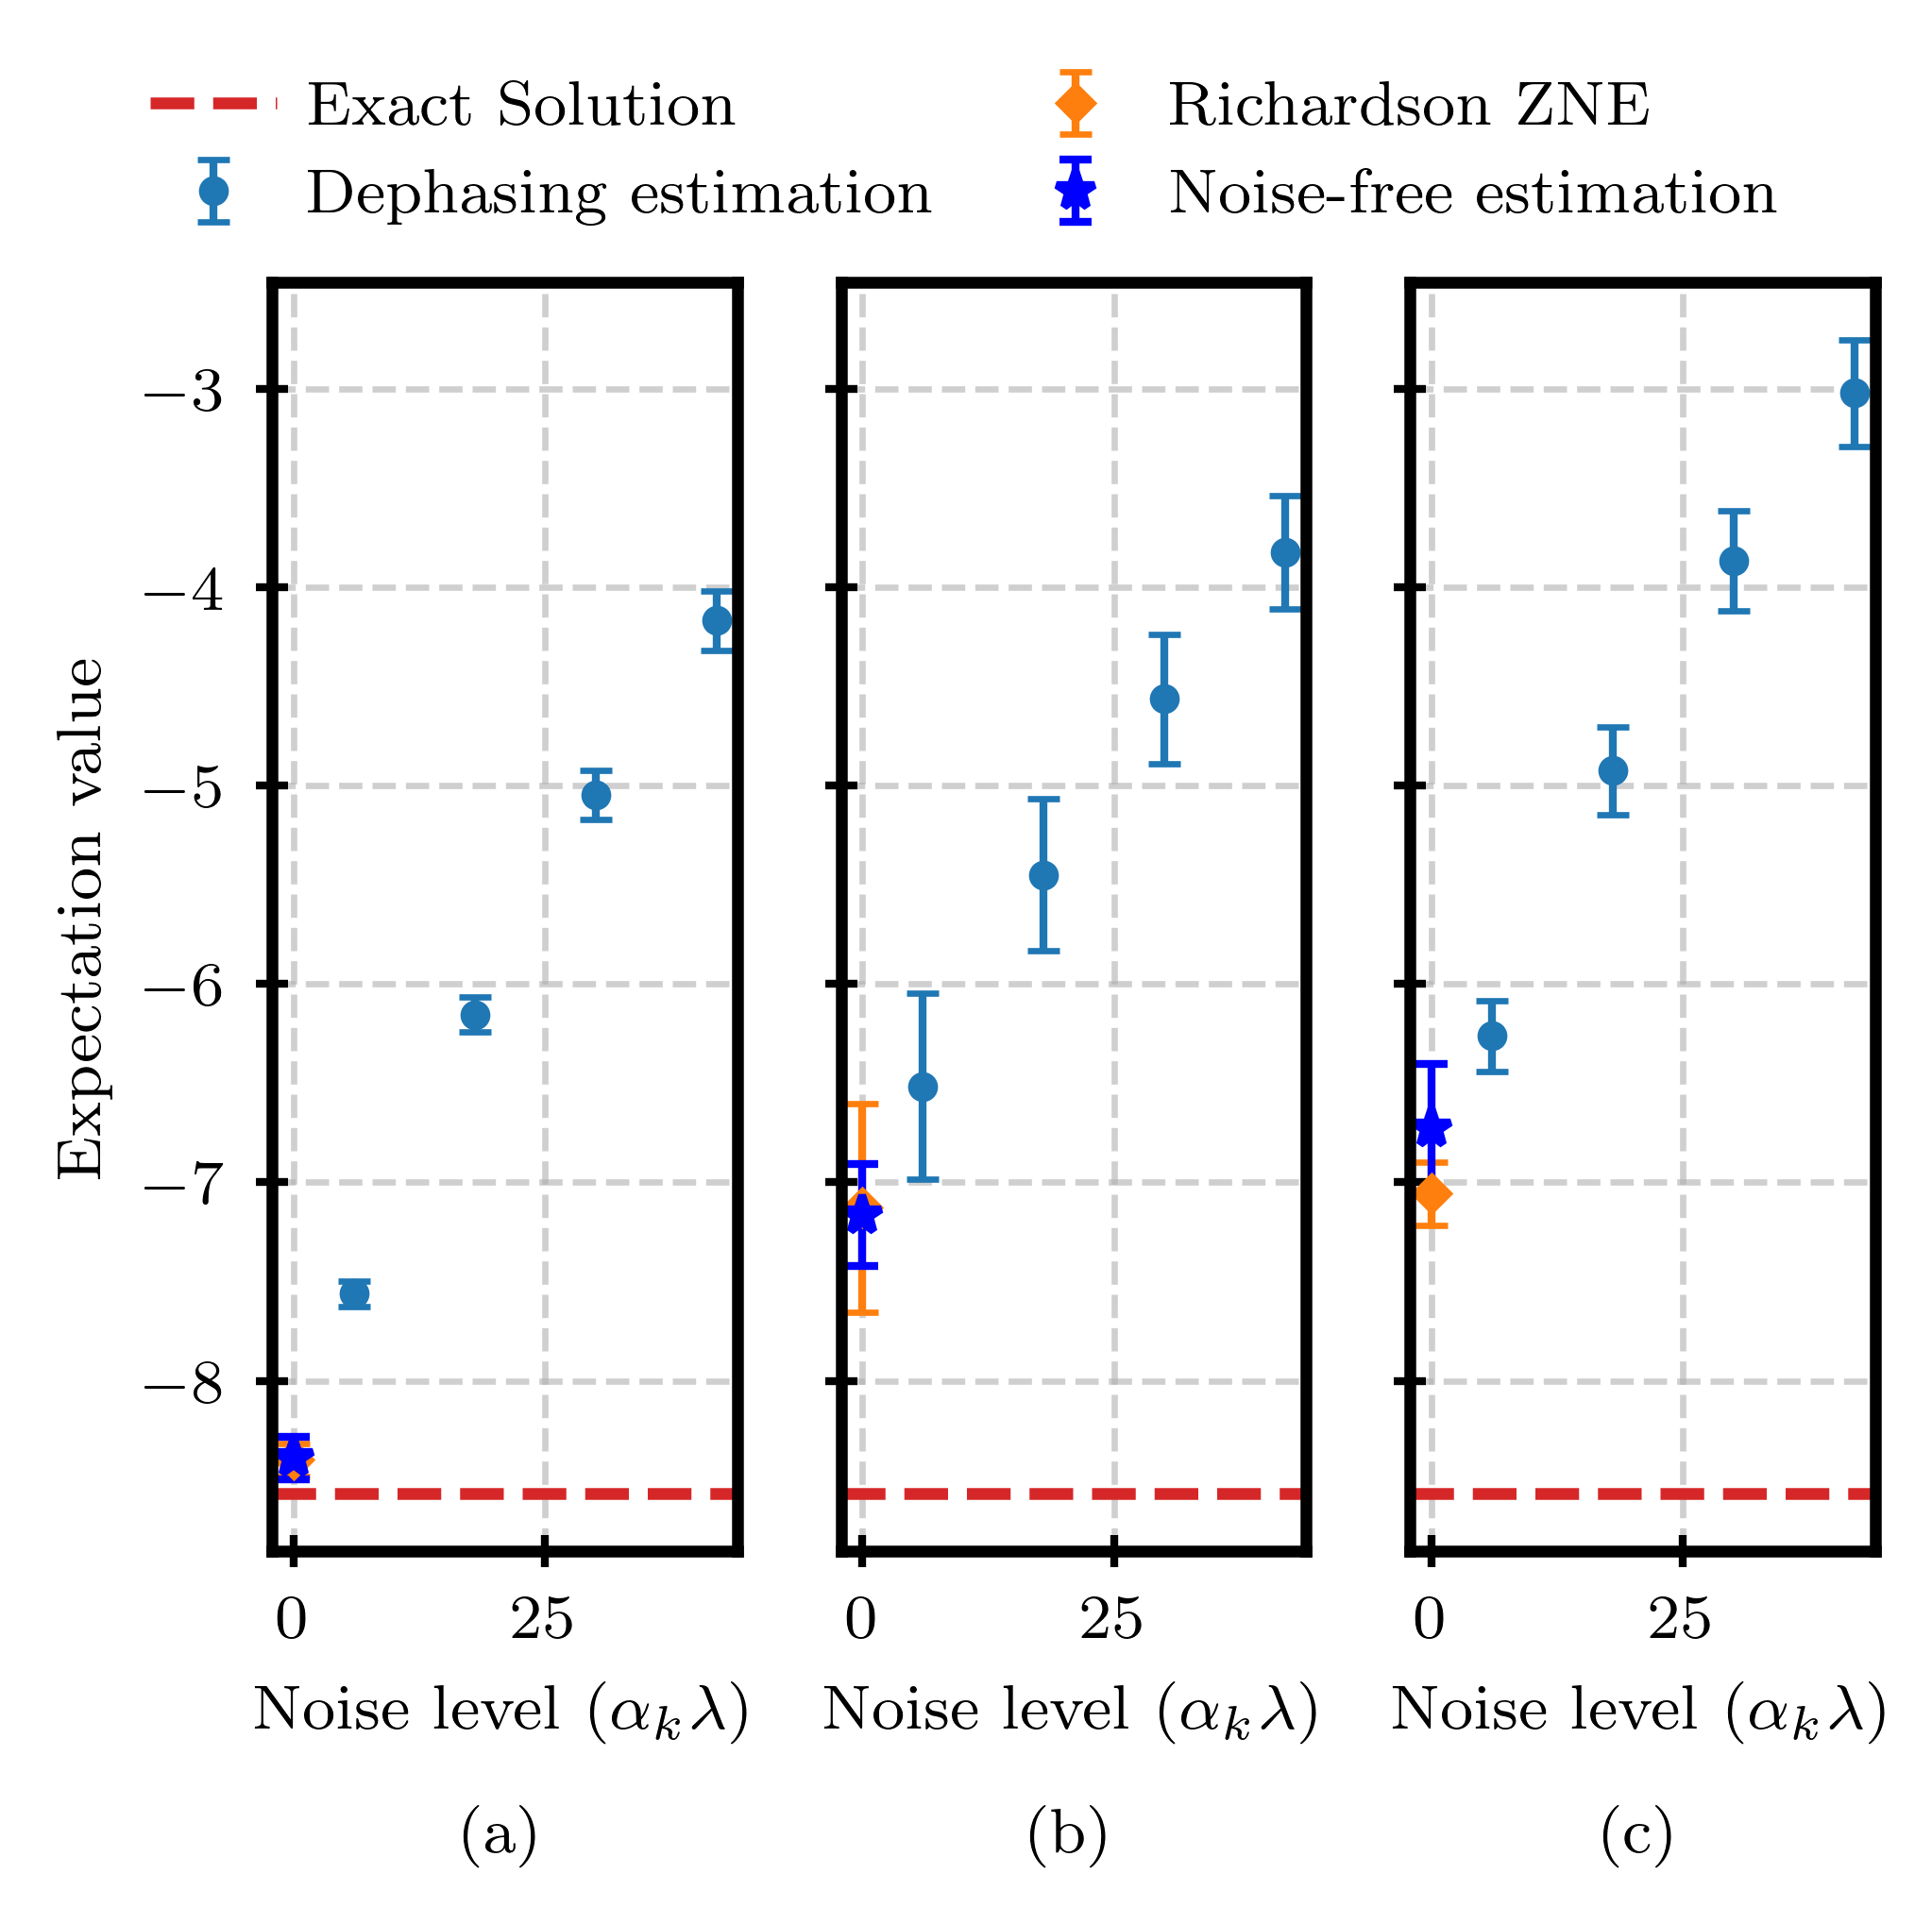

In [15]:
exp_depha = "experiment03[dephasing-time-evo-noise-free]"

subkeys = ['xy-ric4-uniform-scaling', 'ising-ric4-uniform-scaling', 'heisenberg-ric4-uniform-scaling']

data_list = [SIMULATION_DATA_STATS[exp_depha][k] for k in subkeys]

fig = plot_multi_zne(
    data_list             = data_list,
    sharex                = True,
    plot_colors           = COLORS,
    title_fontsize        = TITLE_FONT_SIZE,
    label_fontsize        = LABEL_FONT_SIZE,
    tick_fontsize         = TICK_FONT_SIZE,
    legend_fontsize       = LEGEND_FONT_SIZE,
    marker_size           = 3,
    capsize               = 2,
    plot_file_name        = "zne_noisefree_xy_dphasing_IEE",
    output_dir            = OUTPUT_DIR,
    plot_titles           = ["(a)", "(b)", "(c)"],
    panel_label_y         = -0.20,
    ncols                 = 3,
    figsize               = (3.45, 3.5),
    dpi                   = 600,
    sharey                = True,
    show_legend           = True,
    global_legend         = True,
    legend_loc            = "upper center",
    legend_bbox           = (0.5, 0.95),
    legend_ncols          = 2,
    subplot_top           = 0.82,
    subplot_bottom        = 0.18,
    save_format           = "eps",
    show_plot             = True,
)

### ZNE of Different Orders

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'master-reports' folder): xy-depol-diff-orders.eps


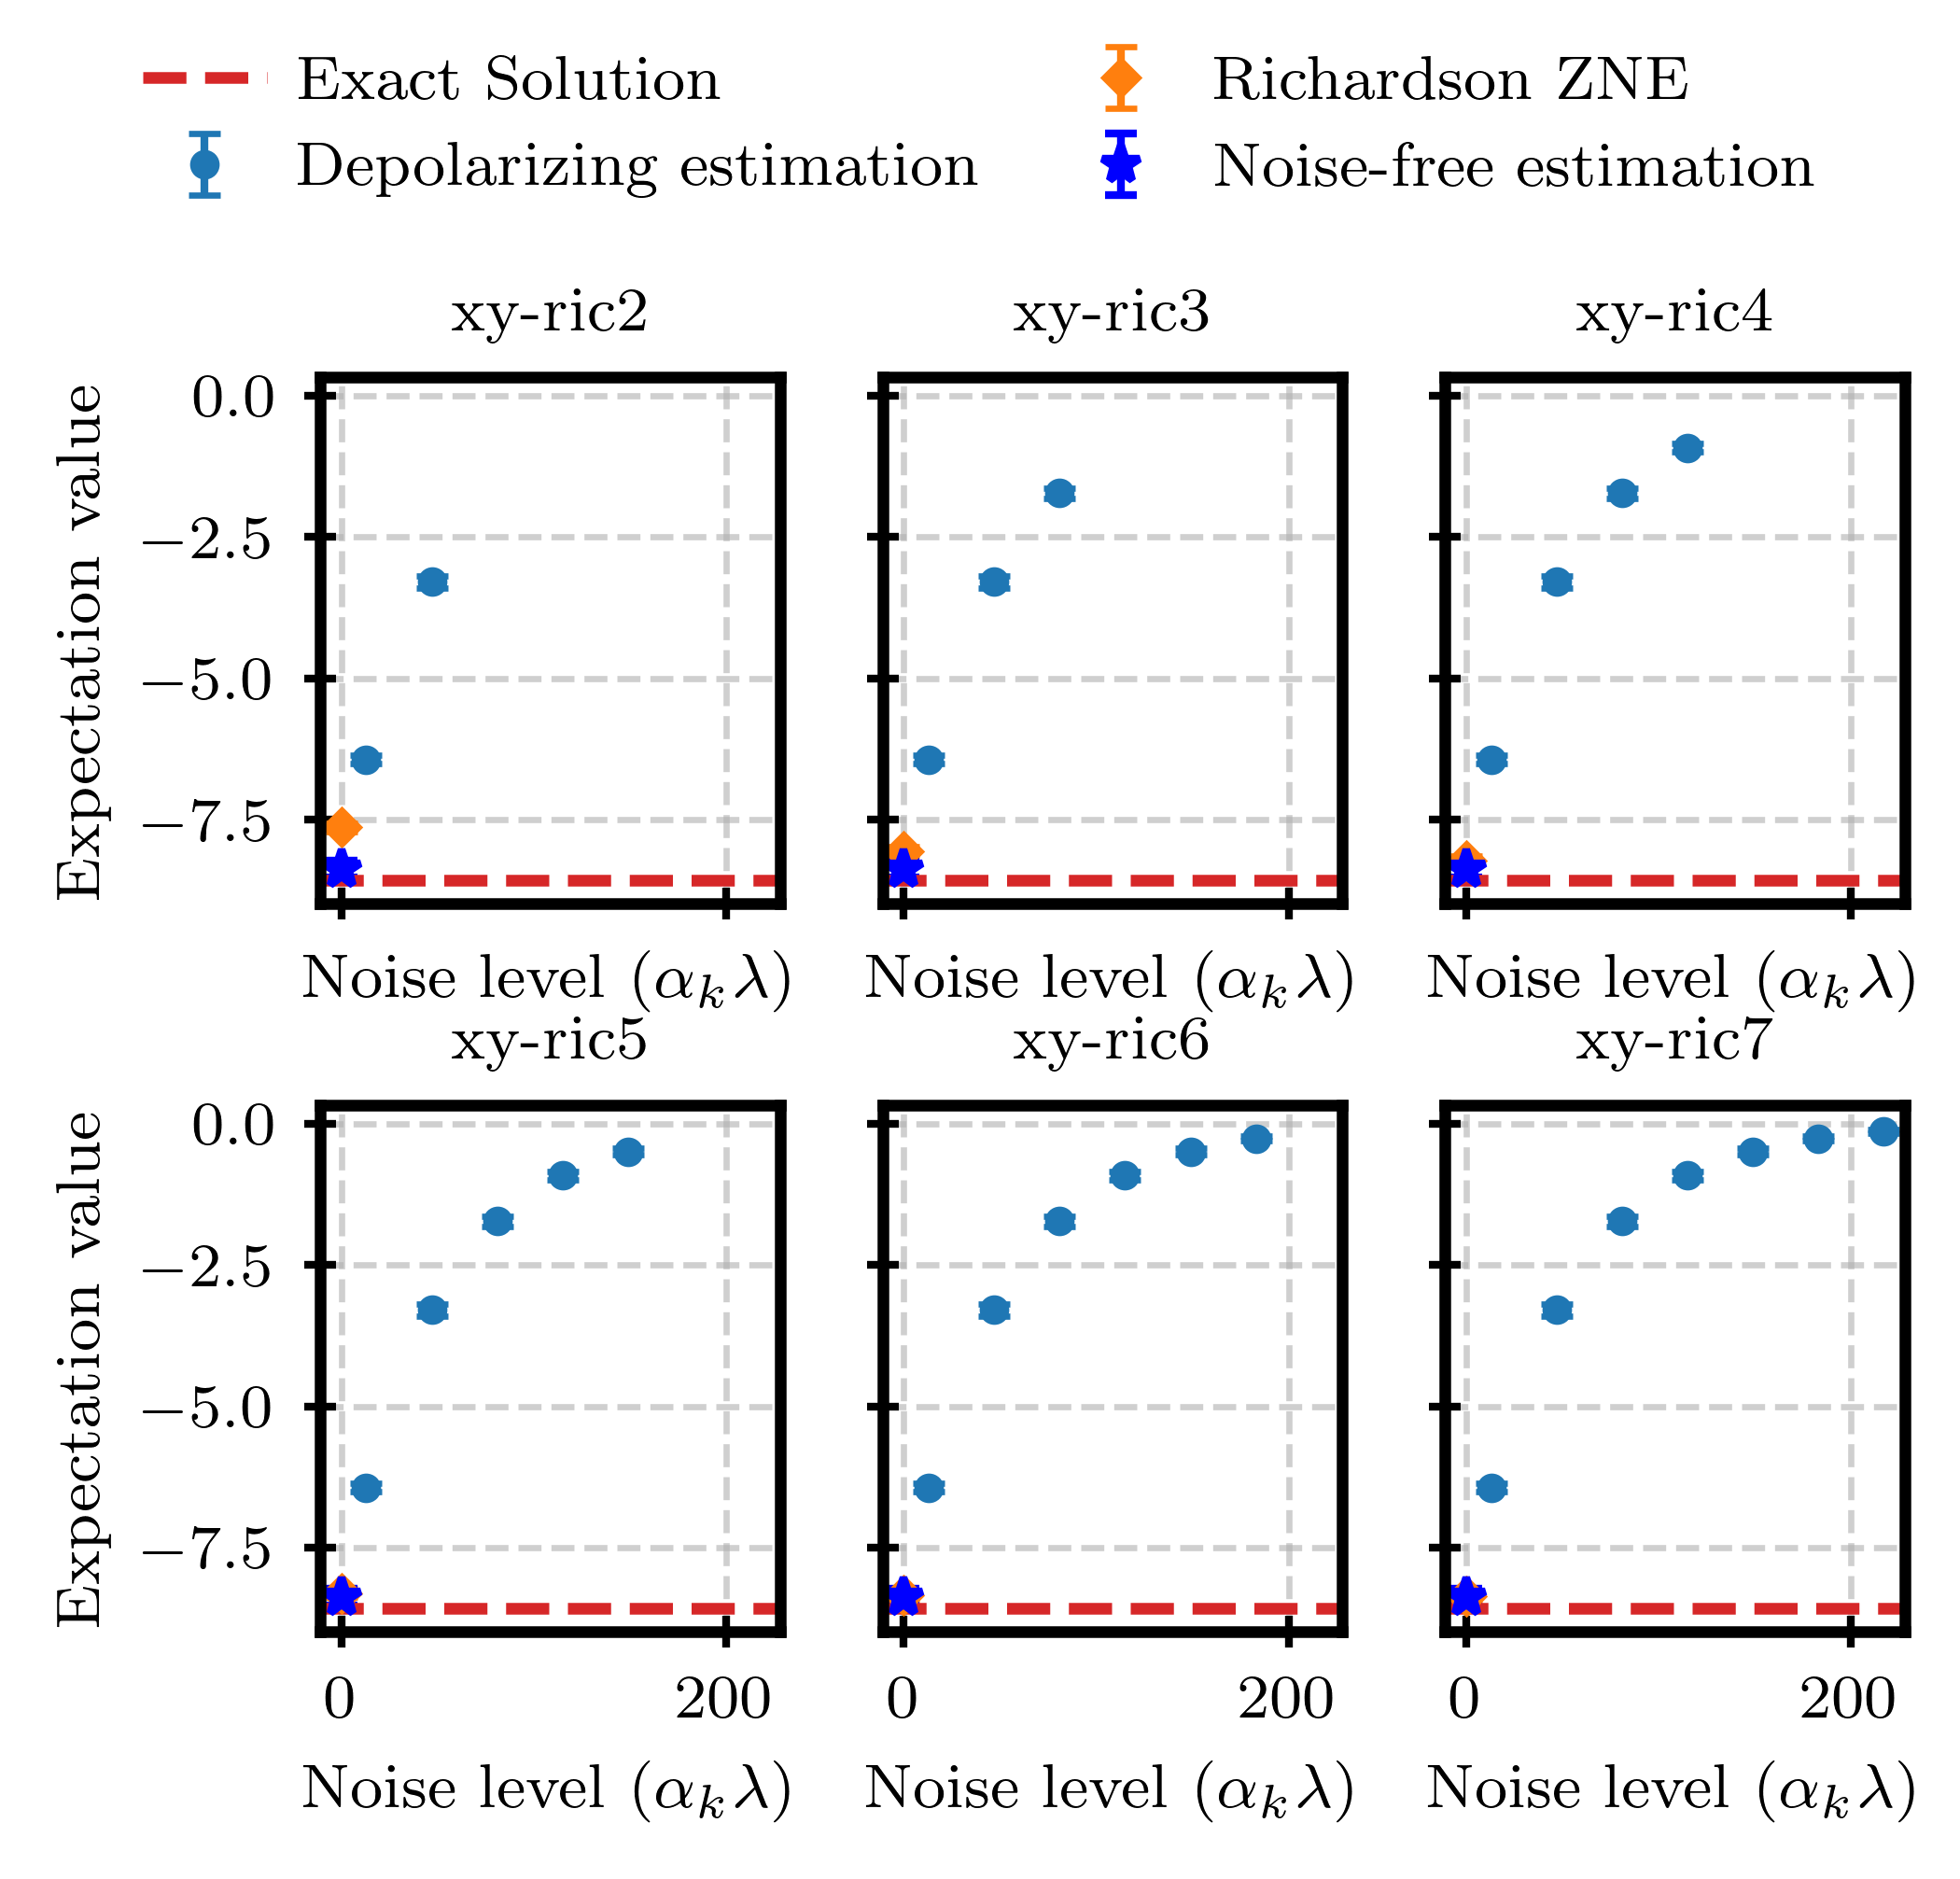

In [16]:
exp_depha = "experiment01[depolarizing-time-evo-noisy]"

subkeys = ["xy-ric2", "xy-ric3", "xy-ric4", "xy-ric5", "xy-ric6", "xy-ric7"]

data_list = [SIMULATION_DATA_STATS[exp_depha][k] for k in subkeys]

fig = plot_multi_zne(
    data_list             = data_list,
    plot_titles           = subkeys,
    sharex                = True,
    plot_colors           = COLORS,
    title_fontsize        = TITLE_FONT_SIZE,
    label_fontsize        = LABEL_FONT_SIZE,
    tick_fontsize         = TICK_FONT_SIZE,
    legend_fontsize       = LEGEND_FONT_SIZE,
    marker_size           = 3,
    capsize               = 2,
    plot_file_name        = "xy-depol-diff-orders",
    output_dir            = OUTPUT_DIR,
    #plot_titles           = ["(a)", "(b)", "(c)"],
    #panel_label_y         = -0.20,
    ncols                 = 3,
    figsize               = (3.45, 3.5),
    dpi                   = 600,
    sharey                = True,
    show_legend           = True,
    global_legend         = True,
    legend_loc            = "upper center",
    #legend_bbox           = (0.5, 0.95),
    legend_ncols          = 2,
    subplot_top           = 0.82,
    subplot_bottom        = 0.18,
    save_format           = "eps",
    show_plot             = True,
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'master-reports' folder): xy-deph-diff-orders.eps


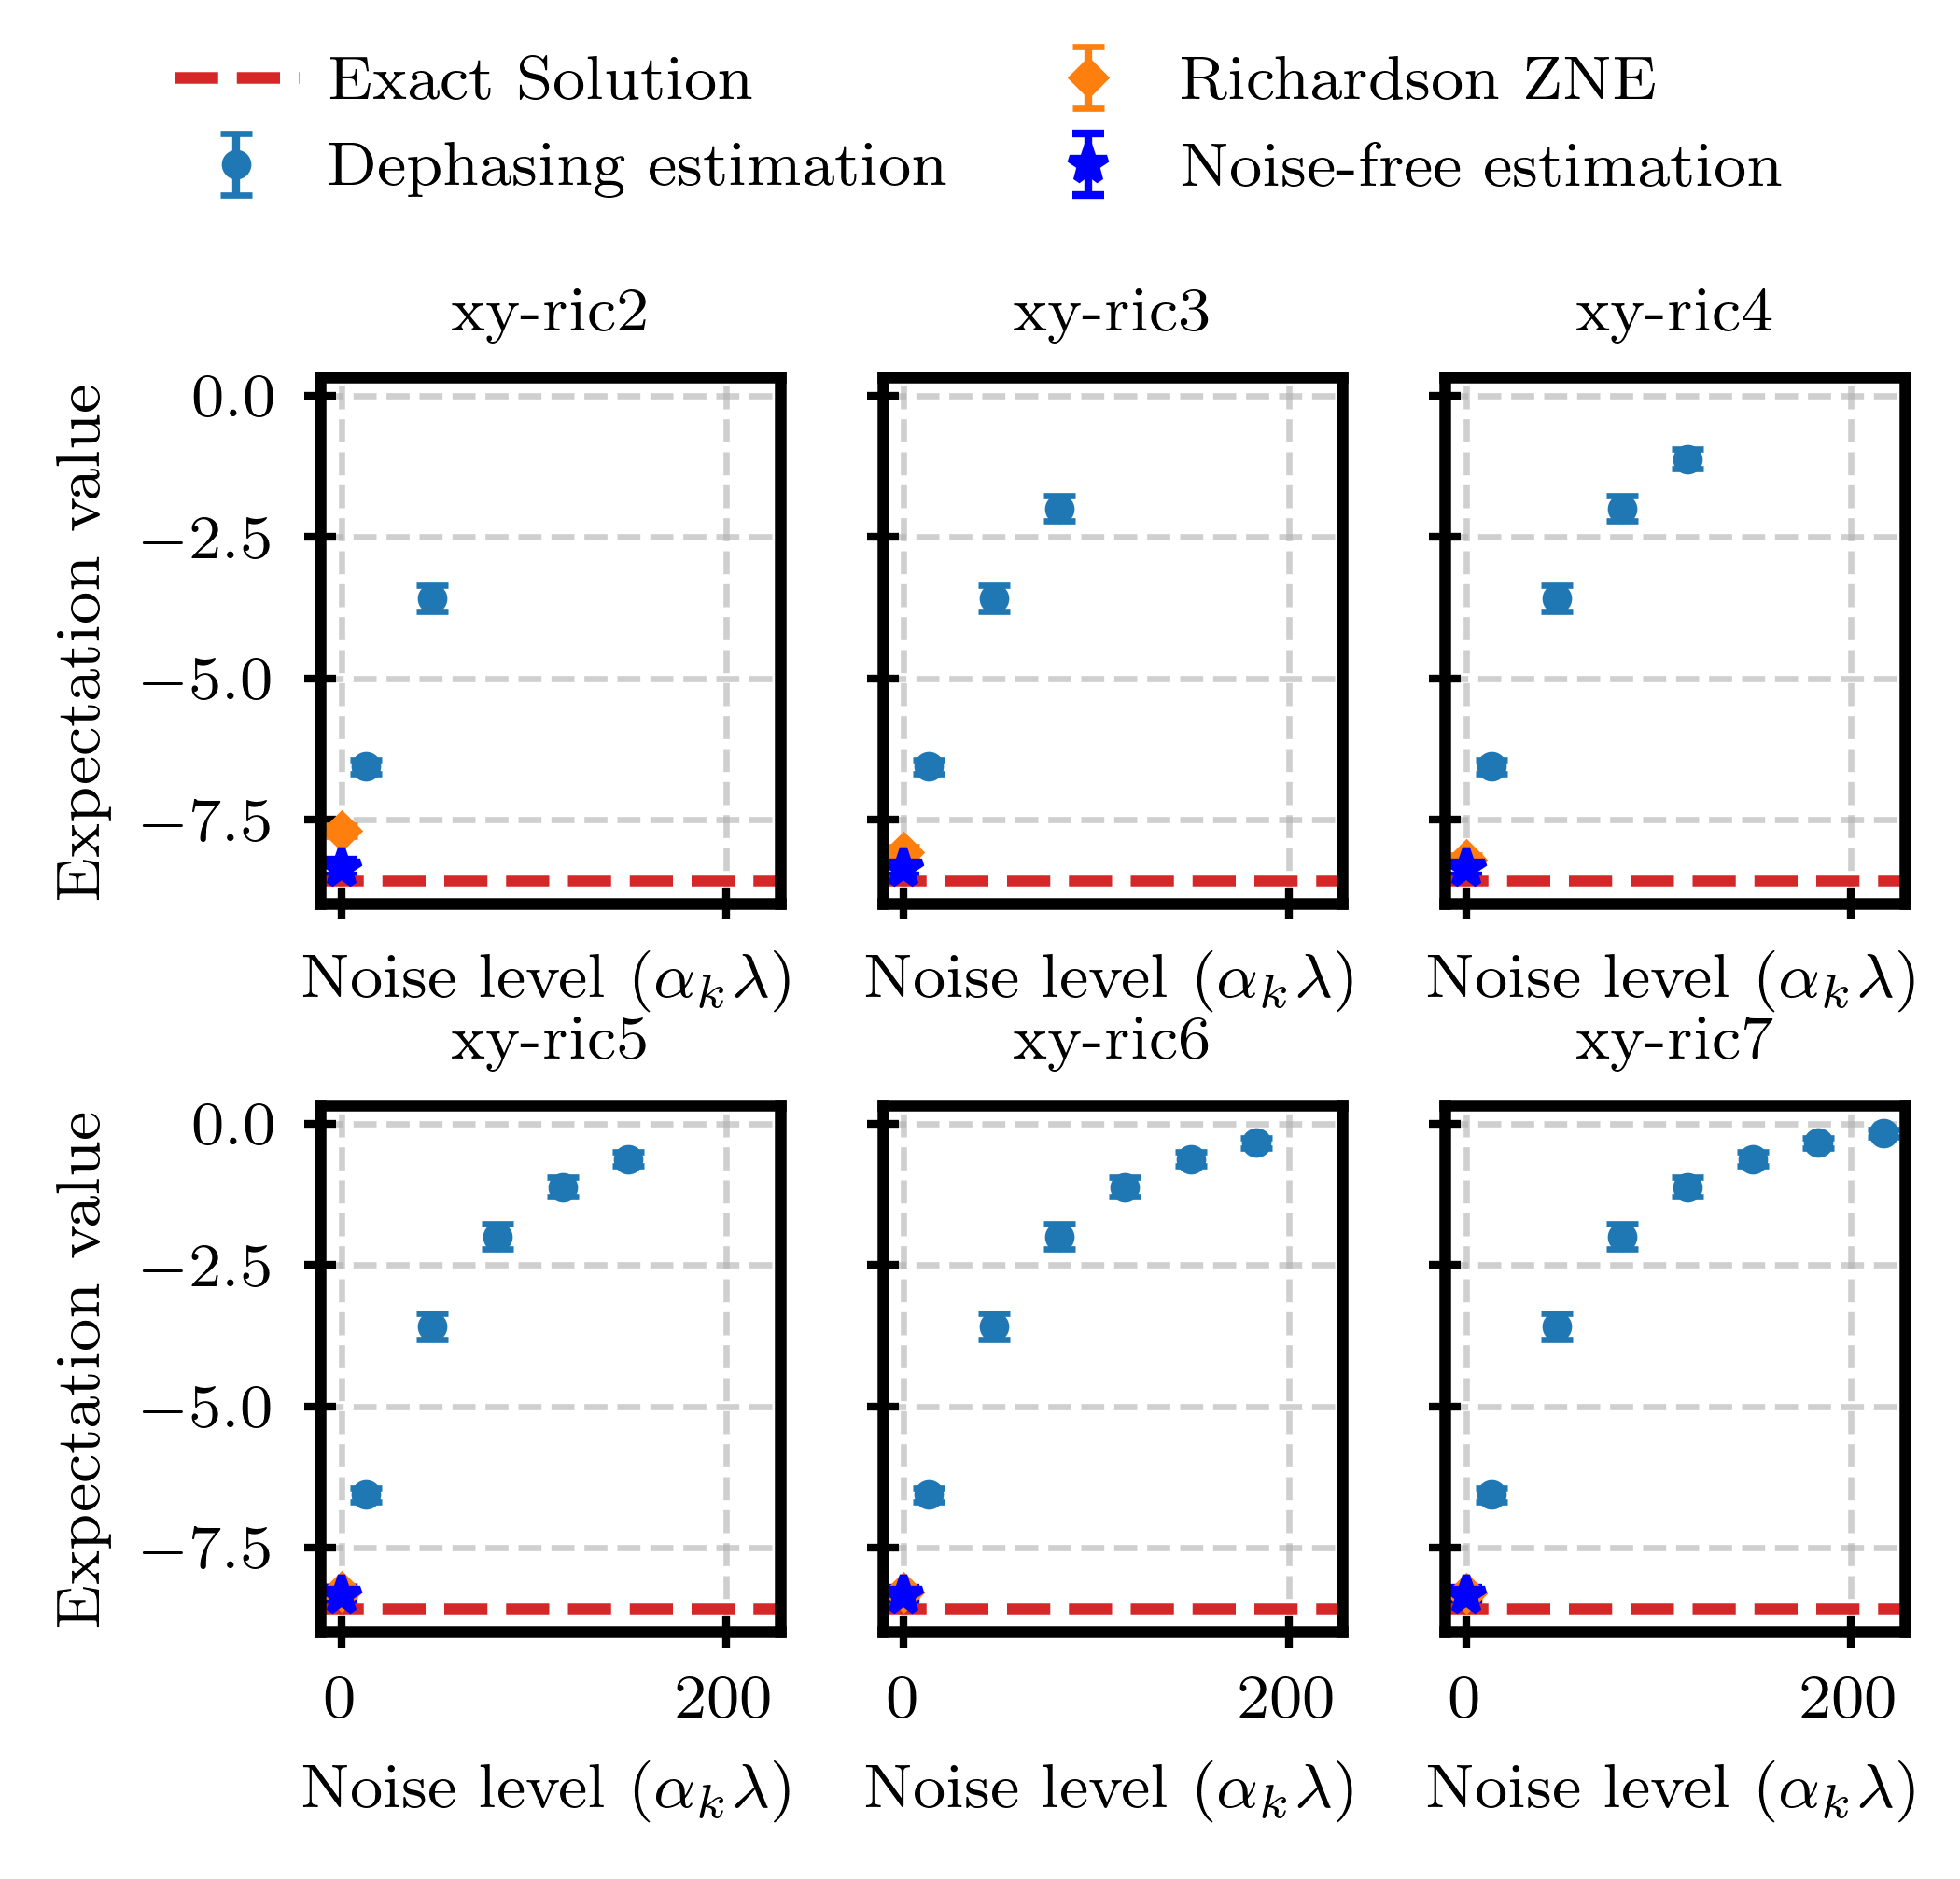

In [17]:
exp_depha = "experiment04[dephasing-time-evo-noisy]"

subkeys = ["xy-ric2", "xy-ric3", "xy-ric4", "xy-ric5", "xy-ric6", "xy-ric7"]

data_list = [SIMULATION_DATA_STATS[exp_depha][k] for k in subkeys]

fig = plot_multi_zne(
    data_list             = data_list,
    plot_titles           = subkeys,
    sharex                = True,
    plot_colors           = COLORS,
    title_fontsize        = TITLE_FONT_SIZE,
    label_fontsize        = LABEL_FONT_SIZE,
    tick_fontsize         = TICK_FONT_SIZE,
    legend_fontsize       = LEGEND_FONT_SIZE,
    marker_size           = 3,
    capsize               = 2,
    plot_file_name        = "xy-deph-diff-orders",
    output_dir            = OUTPUT_DIR,
    #plot_titles           = ["(a)", "(b)", "(c)"],
    #panel_label_y         = -0.20,
    ncols                 = 3,
    figsize               = (3.45, 3.5),
    dpi                   = 600,
    sharey                = True,
    show_legend           = True,
    global_legend         = True,
    legend_loc            = "upper center",
    #legend_bbox           = (0.5, 0.95),
    legend_ncols          = 2,
    subplot_top           = 0.82,
    subplot_bottom        = 0.18,
    save_format           = "eps",
    show_plot             = True,
)